Data source: https://www.kaggle.com/datasets/parisrohan/credit-score-classification

##Imoprting Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

ValueError: mount failed

##Reading Data

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Credit_Score_Classification/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Credit_Score_Classification/test.csv')

df_original = df_train.copy()

In [ ]:
# print(df_train.shape,df_test.shape)

In [ ]:
# df_train.info()

##EDA

In [ ]:
# print(df_train.columns)
# print('\n')

# for col in df_train.columns:
#   print(f'{col} : {col in df_test.columns}')

In [ ]:
# df_train.isnull().sum()

In [ ]:
# for i in df_train.columns:
#   print(f'unique {i} : {df_train[i].nunique()}')

##Data Cleaning

In [ ]:
import numpy as np
import pandas as pd

def preprocess_credit_data(df):
    df = df.copy()

#-------------------------------------------------------------------------------------------------------------------------------------
    df['Age'] = df['Age'].astype(str).apply(lambda x: x.replace('_', '')).astype('int64')
    most_freq_age = df.groupby('Customer_ID')['Age'].agg(lambda x: x.mode().iat[0]).reset_index(name='age_mode')
    df = df.merge(most_freq_age, on='Customer_ID', how='left')
    df['Age'] = np.where((df['Age'] < 0) | (df['Age'] > 80), df['age_mode'], df['Age'])
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_occ = df.groupby('Customer_ID')['Occupation'].agg(lambda x: x.mode().iat[0]).reset_index(name='occu_mode')
    df = df.merge(most_freq_occ, on='Customer_ID', how='left')
    df['Occupation'] = df['Occupation'].replace('_______', np.nan).fillna(df['occu_mode'])
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Annual_Income'] = df['Annual_Income'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
    most_freq_ann_inc = df.groupby('Customer_ID')['Annual_Income'].agg(lambda x: x.mode().iat[0]).reset_index(name='annual_income_mode')
    df = df.merge(most_freq_ann_inc, on='Customer_ID', how='left')
    df['Annual_Income'] = np.where(df['Annual_Income'] > 150000, df['annual_income_mode'], df['Annual_Income'])
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_salary_value = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].agg(lambda x: x.mode().iat[0]).reset_index(name='salary_mode')
    df = df.merge(most_freq_salary_value, on='Customer_ID', how='left')
    df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].astype('float64').fillna(df['salary_mode'])
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_bk_acct = df.groupby('Customer_ID')['Num_Bank_Accounts'].agg(lambda x: x.mode().iat[0]).reset_index(name='bk_acct_mode')
    df = df.merge(most_freq_bk_acct, on='Customer_ID', how='left')
    df['Num_Bank_Accounts'] = np.where(df['Num_Bank_Accounts'] <= 0, 0, df['Num_Bank_Accounts'])
    df['Num_Bank_Accounts'] = np.where(df['Num_Bank_Accounts'] > 20, df['bk_acct_mode'], df['Num_Bank_Accounts'])
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_cc = df.groupby('Customer_ID')['Num_Credit_Card'].agg(lambda x: x.mode().iat[0]).reset_index(name='cc_mode')
    df = df.merge(most_freq_cc, on='Customer_ID', how='left')
    df['Num_Credit_Card'] = np.where(df['Num_Credit_Card'] > 20, df['cc_mode'], df['Num_Credit_Card'])
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_int = df.groupby('Customer_ID')['Interest_Rate'].agg(lambda x: x.mode().iat[0]).reset_index(name='int_mode')
    df = df.merge(most_freq_int, on='Customer_ID', how='left')
    df['Interest_Rate'] = np.where(df['Interest_Rate'] > 50, df['int_mode'], df['Interest_Rate'])
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
    most_freq_ln_value = df.groupby('Customer_ID')['Num_of_Loan'].agg(pd.Series.mode).reset_index(name='num_loans_mode')
    df = df.merge(most_freq_ln_value, on='Customer_ID', how='left')
    df['Num_of_Loan'] = np.where((df['Num_of_Loan'] == -100) | (df['Num_of_Loan'] > 20), df['num_loans_mode'], df['Num_of_Loan'])
#-------------------------------------------------------------------------------------------------------------------------------------
    loan_types = ['Not Specified', 'Credit-Builder Loan', 'Personal Loan', 'Debt Consolidation Loan',
                  'Student Loan', 'Payday Loan', 'Mortgage Loan', 'Auto Loan', 'Home Equity Loan']
    df['Type_of_Loan'] = df['Type_of_Loan'].apply(lambda x: x if x in loan_types else 'Other')
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Delay_from_due_date'] = np.where(df['Delay_from_due_date'] <= 0, 0, df['Delay_from_due_date'])
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
    df['Num_of_Delayed_Payment'] = np.where(df['Num_of_Delayed_Payment'] <= 0, 0, df['Num_of_Delayed_Payment'])
    df['Num_of_Delayed_Payment'] = np.where(df['Num_of_Delayed_Payment'] >= 50, 50, df['Num_of_Delayed_Payment'])
    df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(0)
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Changed_Credit_Limit'] = pd.to_numeric(df['Changed_Credit_Limit'].apply(lambda x: x.replace('_', '')), errors='coerce').fillna(0)
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Num_Credit_Inquiries'] = np.where(df['Num_Credit_Inquiries'] >= 30, 30, df['Num_Credit_Inquiries'])
    df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].fillna(0)
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Non Standard')
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Outstanding_Debt'] = df['Outstanding_Debt'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
#-------------------------------------------------------------------------------------------------------------------------------------
    def years_to_months(value):
        try:
            parts = value.split()
            return int(parts[0]) * 12 + int(parts[3])
        except (ValueError, IndexError, AttributeError):
            return np.nan

    df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(years_to_months)
    df['Credit_History_Age_Months'] = df.groupby('Customer_ID')['Credit_History_Age_Months'].ffill().bfill()
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'No')
#-------------------------------------------------------------------------------------------------------------------------------------
    most_freq_emi = df.groupby('Customer_ID')['Total_EMI_per_month'].agg(lambda x: x.mode().iat[0]).reset_index(name='emi_mode')
    df = df.merge(most_freq_emi, on='Customer_ID', how='left')

    df['Total_EMI_per_month'] = np.where(
        df['Total_EMI_per_month'] == df['emi_mode'],
        df['Total_EMI_per_month'],
        df['emi_mode']
    )
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
    df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
    df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(0)
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Other_payments')
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Monthly_Balance'] = df['Monthly_Balance'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')
    df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
    df['Monthly_Balance'] = np.where((df['Monthly_Balance'] <= 0) | pd.isnull(df['Monthly_Balance']),0,df['Monthly_Balance'])
#-------------------------------------------------------------------------------------------------------------------------------------
    month_mapping = {month: i for i, month in enumerate(
        ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December'], start=1)}
    df['Month_Numeric'] = df['Month'].map(month_mapping)
#-------------------------------------------------------------------------------------------------------------------------------------
    target_mapping = {"Poor": 0, "Standard": 1, "Good": 2}
    df["Credit_Score_encoded"] = df["Credit_Score"].map(target_mapping)
#-------------------------------------------------------------------------------------------------------------------------------------
    df["Occupation_encoded"] = df["Occupation"].map(df.groupby("Occupation")["Credit_Score_encoded"].mean())
#-------------------------------------------------------------------------------------------------------------------------------------
    df["Type_of_Loan_encoded"] = df["Type_of_Loan"].map(df.groupby("Type_of_Loan")["Credit_Score_encoded"].mean())
#-------------------------------------------------------------------------------------------------------------------------------------
    credit_mix_mapping = {"Bad": 0, "Standard": 2, "Good": 3, "Non Standard": 1}
    df["Credit_Mix_encoded"] = df["Credit_Mix"].map(credit_mix_mapping)
#-------------------------------------------------------------------------------------------------------------------------------------
    df['Payment_of_Min_Amount_encoded'] = df['Payment_of_Min_Amount'].map({"No": 0, "Yes": 1})
#-------------------------------------------------------------------------------------------------------------------------------------
    df["Payment_Behaviour_encoded"] = df["Payment_Behaviour"].map(df.groupby("Payment_Behaviour")["Credit_Score_encoded"].mean())
#-------------------------------------------------------------------------------------------------------------------------------------
    cols_remove = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
                   'Credit_History_Age', 'Payment_Behaviour', 'age_mode', 'occu_mode',
                   'annual_income_mode', 'salary_mode', 'bk_acct_mode', 'cc_mode', 'int_mode', 'num_loans_mode',
                   'emi_mode', 'Payment_of_Min_Amount','Credit_Score']


    df_cleaned = df.drop(columns=cols_remove)

    return df_cleaned

In [ ]:
df_processed = preprocess_credit_data(df_train)

##ML Algorithms

In [58]:
# Splitting the dataset into features and target
X = df_processed.drop(columns=['Credit_Score_encoded'])  # Features
y = df_processed['Credit_Score_encoded']  # Target variable

# Splitting into training and test sets
X_train, X_test, y_train, y_test, df_original_train, df_original_test = train_test_split(X, y,df_original, test_size=0.35, random_state=42, stratify=y)

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining and training the Logistic Regression model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
log_reg.fit(X_train_scaled, y_train)

# Making predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)


df_results = df_original_test.copy()  # Start with original test dataset
df_results["Actual_Credit_Score"] = y_test.values  # Add actual values
df_results["Predicted_Credit_Score"] = y_pred  # Add predictions

# Step 9: Map Encoded Credit Scores Back to Labels
target_mapping_reverse = {0: "Poor", 1: "Standard", 2: "Good"}
df_results["Actual_Credit_Score"] = df_results["Actual_Credit_Score"].map(target_mapping_reverse)
df_results["Predicted_Credit_Score"] = df_results["Predicted_Credit_Score"].map(target_mapping_reverse)

Accuracy: 0.6391

Classification Report:
              precision    recall  f1-score   support

        Poor       0.66      0.51      0.58     10149
    Standard       0.64      0.77      0.70     18611
        Good       0.58      0.44      0.50      6240

    accuracy                           0.64     35000
   macro avg       0.63      0.58      0.59     35000
weighted avg       0.64      0.64      0.63     35000


ROC-AUC Score: 0.7974


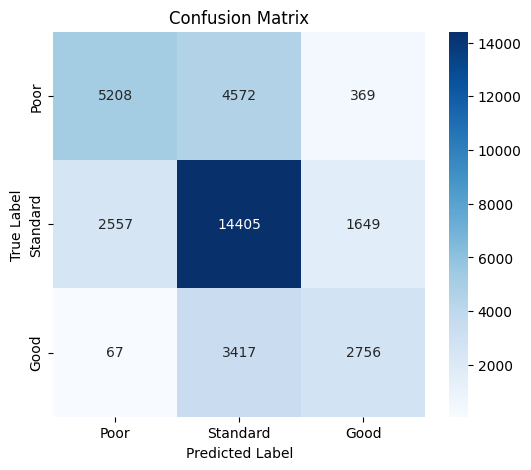

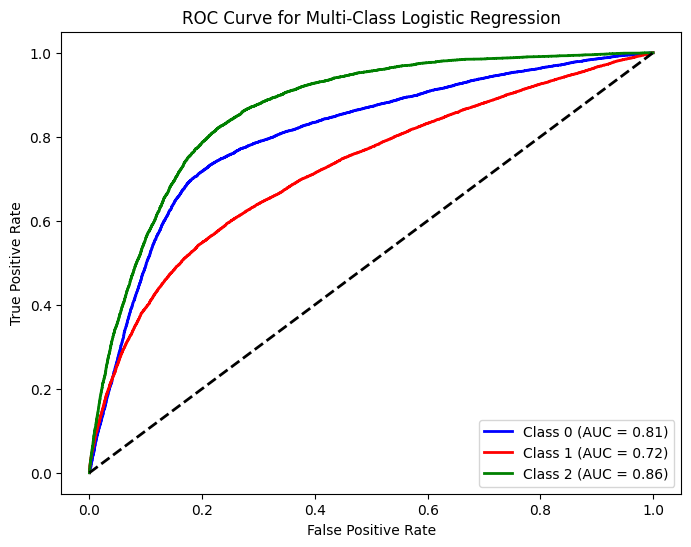

In [60]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Poor", "Standard", "Good"]))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")
print(f'\nROC-AUC Score: {roc_auc:.4f}')


from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Poor", "Standard", "Good"], yticklabels=["Poor", "Standard", "Good"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Convert y_test to one-hot encoding
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Colors for each class
colors = cycle(['blue', 'red', 'green'])
plt.figure(figsize=(8,6))

# Compute ROC Curve for each class
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Plot Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Logistic Regression')
plt.legend(loc="lower right")
plt.show()


In [61]:
df_original = df_train.copy()



# Step 4: Create a DataFrame with Original Test Features and Predictions
df_test_results = X_test.copy()  # Copy test features
df_test_results["Actual_Credit_Score"] = y_test.values  # Add actual values
df_test_results["Predicted_Credit_Score"] = y_pred  # Add predictions

# Step 5: Map Encoded Credit Scores Back to Labels
target_mapping_reverse = {0: "Poor", 1: "Standard", 2: "Good"}
df_test_results["Actual_Credit_Score"] = df_test_results["Actual_Credit_Score"].map(target_mapping_reverse)
df_test_results["Predicted_Credit_Score"] = df_test_results["Predicted_Credit_Score"].map(target_mapping_reverse)

In [62]:
df_test_results.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Month_Numeric,Occupation_encoded,Type_of_Loan_encoded,Credit_Mix_encoded,Payment_of_Min_Amount_encoded,Payment_Behaviour_encoded,Actual_Credit_Score,Predicted_Credit_Score
85540,36,9447.12,823.260000,10,10,34,7.0,54,19.0,19.61,9.0,1510.44,28.976404,34.104328,10000.000000,253.488345,134.0,5,0.872331,0.852518,2,1,0.899185,Poor,Poor
40906,38,45051.24,3874.270000,6,6,6,3.0,22,19.0,16.30,6.0,1014.25,25.188408,73.940708,30.129571,523.356721,381.0,3,0.908851,0.852518,2,1,1.014066,Standard,Standard
54859,23,62458.77,5426.897500,8,6,20,4.0,12,0.0,23.02,7.0,1215.52,34.808829,199.046256,415.409699,198.233795,236.0,4,0.839626,0.852518,1,1,0.899185,Good,Standard
67406,21,37361.02,3280.418333,10,6,19,6.0,54,20.0,17.41,12.0,2911.75,37.459236,129.871891,124.580745,353.589198,53.0,7,0.896455,0.852518,0,1,0.889211,Poor,Poor
98279,24,59868.93,5111.077500,4,7,9,4.0,8,11.0,6.09,4.0,417.72,24.803887,104.622038,10000.000000,80.190256,348.0,8,0.900507,0.852518,3,0,0.770627,Standard,Standard


##Original Data Cleaning

In [ ]:
# def remove_outliers(df, column, num_stds=1.5):
#   q1 = df[column].quantile(0.25)
#   q3 = df[column].quantile(0.75)
#   iqr = q3 - q1  # Interquartile range
#   lower_bound = q1 - (num_stds * iqr)
#   upper_bound = q3 + (num_stds * iqr)
#   return df[~((df[column] < lower_bound) | (df[column] > upper_bound))]

In [ ]:
# df_train_copy['Age'] = df_train_copy['Age'].astype(str).apply(lambda x: x.replace('_', ''))
# df_train_copy['Age'] = df_train_copy['Age'].astype('int64')

# most_freq_age = df_train_copy.groupby('Customer_ID')['Age'].agg(lambda x: x.mode().iat[0]).reset_index(name='age_mode')
# df_train_copy = df_train_copy.merge(most_freq_age, on='Customer_ID', how='left')
# df_train_copy['Age'] = np.where((df_train_copy['Age'] < 0) | (df_train_copy['Age'] > 80), df_train_copy['age_mode'], df_train_copy['Age'])

In [ ]:
# most_freq_occ = df_train_copy.groupby('Customer_ID')['Occupation'].agg(lambda x: x.mode().iat[0]).reset_index(name='occu_mode')
# df_train_copy = df_train_copy.merge(most_freq_occ, on='Customer_ID', how='left')

# df_train_copy['Occupation'] = df_train_copy['Occupation'].replace('_______', np.nan)
# df_train_copy['Occupation'] = df_train_copy['Occupation'].fillna(df_train_copy['occu_mode'])

In [ ]:
# df_train_copy['Annual_Income'] = df_train_copy['Annual_Income'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

# most_freq_ann_inc = df_train_copy.groupby('Customer_ID')['Annual_Income'].agg(lambda x: x.mode().iat[0]).reset_index(name='annual_income_mode')
# df_train_copy = df_train_copy.merge(most_freq_ann_inc, on='Customer_ID', how='left')
# df_train_copy['Annual_Income'] = np.where(df_train_copy['Annual_Income'] > 150000, df_train_copy['annual_income_mode'], df_train_copy['Annual_Income'])

In [ ]:
# most_freq_salary_value = df_train_copy.groupby('Customer_ID')['Monthly_Inhand_Salary'].agg(lambda x: x.mode().iat[0]).reset_index(name='salary_mode')
# df_train_copy = df_train_copy.merge(most_freq_salary_value, on='Customer_ID', how='left')

# # Ensure both columns are float64
# df_train_copy['Monthly_Inhand_Salary'] = df_train_copy['Monthly_Inhand_Salary'].astype('float64')
# df_train_copy['salary_mode'] = df_train_copy['salary_mode'].astype('float64')

# df_train_copy['Monthly_Inhand_Salary'] = df_train_copy['Monthly_Inhand_Salary'].fillna(df_train_copy['salary_mode'])

In [ ]:
# most_freq_bk_acct = df_train_copy.groupby('Customer_ID')['Num_Bank_Accounts'].agg(lambda x: x.mode().iat[0]).reset_index(name='bk_acct_mode')
# df_train_copy = df_train_copy.merge(most_freq_bk_acct, on='Customer_ID', how='left')
# df_train_copy['Num_Bank_Accounts'] = np.where(df_train_copy['Num_Bank_Accounts'] <= 0, 0, df_train_copy['Num_Bank_Accounts'])
# df_train_copy['Num_Bank_Accounts'] = np.where(df_train_copy['Num_Bank_Accounts'] > 20, df_train_copy['bk_acct_mode'], df_train_copy['Num_Bank_Accounts'])

In [ ]:
# most_freq_cc = df_train_copy.groupby('Customer_ID')['Num_Credit_Card'].agg(lambda x: x.mode().iat[0]).reset_index(name='cc_mode')
# df_train_copy = df_train_copy.merge(most_freq_cc, on='Customer_ID', how='left')
# df_train_copy['Num_Credit_Card'] = np.where(df_train_copy['Num_Credit_Card'] > 20, df_train_copy['cc_mode'], df_train_copy['Num_Credit_Card'])

In [ ]:
# most_freq_int = df_train_copy.groupby('Customer_ID')['Interest_Rate'].agg(lambda x: x.mode().iat[0]).reset_index(name='int_mode')
# df_train_copy = df_train_copy.merge(most_freq_int, on='Customer_ID', how='left')
# df_train_copy['Interest_Rate'] = np.where(df_train_copy['Interest_Rate'] > 50, df_train_copy['int_mode'], df_train_copy['Interest_Rate'])

In [ ]:
# df_train_copy['Num_of_Loan'] = df_train_copy['Num_of_Loan'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

# most_freq_ln_value = df_train_copy.groupby('Customer_ID')['Num_of_Loan'].agg(pd.Series.mode).reset_index(name='num_loans_mode')
# df_train_copy = df_train_copy.merge(most_freq_ln_value, on='Customer_ID', how='left')
# df_train_copy['Num_of_Loan'] = np.where((df_train_copy['Num_of_Loan'] == -100) | (df_train_copy['Num_of_Loan'] > 20),df_train_copy['num_loans_mode'],df_train_copy['Num_of_Loan'])

In [ ]:
# loan_types = ['Not Specified','Credit-Builder Loan','Personal Loan','Debt Consolidation Loan','Student Loan','Payday Loan',
#               'Mortgage Loan','Auto Loan','Home Equity Loan']

# def categorize_loan_type(loan):
#   if loan in loan_types:
#     return loan
#   else:
#     return 'Other'

# # Apply the function to the DataFrame
# df_train_copy['Type_of_Loan'] = df_train_copy['Type_of_Loan'].apply(categorize_loan_type)

In [ ]:
# df_train_copy['Delay_from_due_date'] = np.where(df_train_copy['Delay_from_due_date'] <= 0, 0, df_train_copy['Delay_from_due_date'])

In [ ]:
# df_train_copy['Num_of_Delayed_Payment'] = df_train_copy['Num_of_Delayed_Payment'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

# df_train_copy['Num_of_Delayed_Payment'] = np.where(df_train_copy['Num_of_Delayed_Payment'] <= 0, 0, df_train_copy['Num_of_Delayed_Payment'])
# df_train_copy['Num_of_Delayed_Payment'] = np.where(df_train_copy['Num_of_Delayed_Payment'] >= 50, 50, df_train_copy['Num_of_Delayed_Payment'])
# df_train_copy['Num_of_Delayed_Payment'] = df_train_copy['Num_of_Delayed_Payment'].fillna(0)

In [ ]:
# df_train_copy['Changed_Credit_Limit'] = df_train_copy['Changed_Credit_Limit'].apply(lambda x: x.replace('_', ''))
# df_train_copy['Changed_Credit_Limit'] = pd.to_numeric(df_train_copy['Changed_Credit_Limit'], errors='coerce')
# #
# df_train_copy['Changed_Credit_Limit'] = np.where(df_train_copy['Changed_Credit_Limit'] <= 0, 0, df_train_copy['Changed_Credit_Limit'])
# df_train_copy['Changed_Credit_Limit'] = df_train_copy['Changed_Credit_Limit'].fillna(0)

In [ ]:
# df_train_copy['Num_Credit_Inquiries'] = np.where(df_train_copy['Num_Credit_Inquiries'] >= 30, 30, df_train_copy['Num_Credit_Inquiries'])
# df_train_copy['Num_Credit_Inquiries'] = df_train_copy['Num_Credit_Inquiries'].fillna(0)

In [ ]:
# df_train_copy['Credit_Mix'] = df_train_copy['Credit_Mix'].replace('_', 'Non Standard')

In [ ]:
# df_train_copy['Outstanding_Debt'] = df_train_copy['Outstanding_Debt'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

In [ ]:
# def years_to_months(value):
#   if isinstance(value, str):
#     try:
#       parts = value.split()
#       years = int(parts[0])
#       months = int(parts[3])
#       return years * 12 + months
#     except (ValueError, IndexError):
#       return np.nan
#   else:
#     return value

In [ ]:
# df_train_copy['Credit_History_Age_Months'] = df_train_copy['Credit_History_Age'].apply(years_to_months)
# df_train_copy['Credit_History_Age_Months'] = df_train_copy.groupby('Customer_ID')['Credit_History_Age_Months'].ffill().bfill()

In [ ]:
# df_train_copy['Payment_of_Min_Amount'] = df_train_copy['Payment_of_Min_Amount'].replace('NM', 'No')

In [ ]:
# most_freq_emi = df_train_copy.groupby('Customer_ID')['Total_EMI_per_month'].agg(lambda x: x.mode().iat[0]).reset_index(name='emi_mode')
# df_train_copy = df_train_copy.merge(most_freq_emi, on='Customer_ID', how='left')

# df_train_copy['Total_EMI_per_month'] = np.where(
#     df_train_copy['Total_EMI_per_month'] == df_train_copy['emi_mode'],
#     df_train_copy['Total_EMI_per_month'],
#     df_train_copy['emi_mode']
# )

In [ ]:
# df_train_copy['Amount_invested_monthly'] = df_train_copy['Amount_invested_monthly'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

# df_train_copy['Amount_invested_monthly'] = pd.to_numeric(df_train_copy['Amount_invested_monthly'], errors='coerce')
# df_train_copy['Amount_invested_monthly'] = df_train_copy['Amount_invested_monthly'].fillna(0)

In [ ]:
# df_train_copy['Payment_Behaviour'] = df_train_copy['Payment_Behaviour'].replace('!@9#%8', 'Other_payments')

In [ ]:
# df_train_copy['Monthly_Balance'] = df_train_copy['Monthly_Balance'].astype(str).apply(lambda x: x.replace('_', '')).astype('float64')

# df_train_copy['Monthly_Balance'] = pd.to_numeric(df_train_copy['Monthly_Balance'], errors='coerce')
# df_train_copy['Monthly_Balance'] = np.where((df_train_copy['Monthly_Balance'] <= 0) | pd.isnull(df_train_copy['Monthly_Balance']),0,df_train_copy['Monthly_Balance'])

In [ ]:
# df_sample = df_train_copy.head(20).to_csv('sample_data.csv', index=False)
# df_train_copy['Payment_Behaviour'].unique()

In [ ]:
# month_mapping = {
#     'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
#     'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
# }

# # if 'Month' in df_train_copy.columns:
# df_train_copy['Month_Numeric'] = df_train_copy['Month'].map(month_mapping)

In [ ]:
# target_mapping = {"Poor": 0, "Standard": 1, "Good": 2}
# df_train_copy["Credit_Score_encoded"] = df_train_copy["Credit_Score"].map(target_mapping)

In [ ]:
# occupation_target_mean = df_train_copy.groupby("Occupation")["Credit_Score_encoded"].mean()
# df_train_copy["Occupation_encoded"] = df_train_copy["Occupation"].map(occupation_target_mean)

In [ ]:
# loan_target_mean = df_train_copy.groupby("Type_of_Loan")["Credit_Score_encoded"].mean()
# df_train_copy["Type_of_Loan_encoded"] = df_train_copy["Type_of_Loan"].map(loan_target_mean)

In [ ]:
# credit_mix_mapping = {"Bad": 0, "Standard": 2, "Good": 3,"Non Standard": 1}
# df_train_copy["Credit_Mix_encoded"] = df_train_copy["Credit_Mix"].map(credit_mix_mapping)

In [ ]:
# payment_of_min_amount_mapping = {"No": 0, "Yes": 1}
# df_train_copy['Payment_of_Min_Amount_encoded'] = df_train_copy['Payment_of_Min_Amount'].map(payment_of_min_amount_mapping)

In [ ]:
# payment_target_mean = df_train_copy.groupby("Payment_Behaviour")["Credit_Score_encoded"].mean()
# df_train_copy["Payment_Behaviour_encoded"] = df_train_copy["Payment_Behaviour"].map(payment_target_mean)

In [ ]:
# cols_remove = ['ID','Customer_ID','Month','Name','SSN','Occupation','Type_of_Loan','Credit_Mix','Credit_History_Age','Payment_Behaviour','Credit_Score','age_mode', 'occu_mode', 'annual_income_mode',
#        'salary_mode', 'bk_acct_mode', 'cc_mode', 'int_mode', 'num_loans_mode',
#        'emi_mode','Payment_of_Min_Amount']

# df_train_copy_all_cols = df_train_copy.drop(columns=cols_remove)

In [ ]:
# df_train_copy_all_cols_target = df_train_copy_all_cols['Credit_Score_encoded']
# df_train_copy_all_cols = df_train_copy_all_cols.drop(columns=['Credit_Score_encoded'])

In [ ]:
# df_train_copy_all_cols.head(1)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Month_Numeric,Occupation_encoded,Type_of_Loan_encoded,Credit_Mix_encoded,Payment_of_Min_Amount_encoded,Payment_Behaviour_encoded
0,23,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,809.98,26.82262,49.574949,80.415295,312.494089,265.0,1,0.872331,0.852518,1,0,0.914109


In [ ]:
# df_train_copy_all_cols.head(10).to_csv('sample2.csv')

In [53]:
# df_processed_cleaned = df_processed.drop(columns=['Credit_Score'])

scaler = StandardScaler()
df_processed_scaled = scaler.fit_transform(df_processed)

In [54]:
df_processed_scaled

array([[-0.95786714, -0.81962491, -0.74465645, ..., -0.63362211,
        -1.04765423,  0.3217077 ],
       [-0.95786714, -0.81962491, -0.74465645, ...,  1.28168564,
        -1.04765423,  0.13567474],
       [-0.95786714, -0.81962491, -0.74465645, ...,  1.28168564,
        -1.04765423, -0.16252165],
       ...,
       [-0.77207518, -0.28397786, -0.26320473, ...,  1.28168564,
        -1.04765423,  1.56764523],
       [-0.77207518, -0.28397786, -0.26320473, ...,  1.28168564,
        -1.04765423,  0.13567474],
       [-0.77207518, -0.28397786, -0.26320473, ...,  1.28168564,
        -1.04765423,  0.01134951]])

##Classification Algorithms

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_train_copy_all_cols_scaled, df_train_copy_all_cols_target, test_size=0.3, random_state=42, stratify=df_train_copy_all_cols_target)


==== Logistic Regression ====
Accuracy: 0.6382
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.51      0.58      8699
           1       0.64      0.77      0.70     15952
           2       0.57      0.44      0.50      5349

    accuracy                           0.64     30000
   macro avg       0.63      0.58      0.59     30000
weighted avg       0.64      0.64      0.63     30000

ROC AUC Score: 0.7969760856063389

==== Decision Tree ====
Accuracy: 0.6897666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67      8699
           1       0.73      0.73      0.73     15952
           2       0.61      0.62      0.61      5349

    accuracy                           0.69     30000
   macro avg       0.67      0.67      0.67     30000
weighted avg       0.69      0.69      0.69     30000

ROC AUC Score: 0.7471332327489089

==== Random Forest 

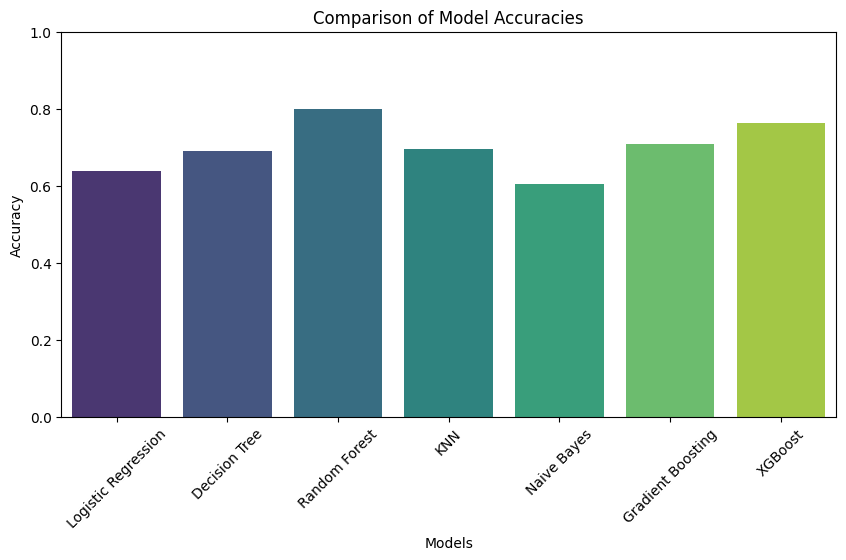

In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
    # "SVM": SVC(probability=True),
}


# Dictionary to store model accuracies
model_accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Ensure that y_prob contains probability scores for all classes
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy  # Store accuracy


    print(f"\n==== {name} ====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    if y_prob is not None:
        print("ROC AUC Score:", roc_auc_score(y_test, y_prob, multi_class='ovr'))


# Plot model accuracies
plt.figure(figsize=(10, 5))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Accuracy is between 0 and 1
plt.show()


In [ ]:
# Define hyperparameter grid for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\nFinal Model Performance:")
print(classification_report(y_test, y_pred_best))


In [ ]:
# Perform cross-validation
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy")
    cv_results[name] = np.mean(scores)

# Print cross-validation results
print("\n=== Cross-Validation Accuracy Scores ===")
for model, score in cv_results.items():
    print(f"{model}: {score:.4f}")


In [ ]:
# q1 = df_train_copy['Credit_Utilization_Ratio'].quantile(0.25)
# q3 = df_train_copy['Credit_Utilization_Ratio'].quantile(0.75)
# iqr = q3 - q1  # Interquartile range
# lower_bound = q1 - (1.5 * iqr)
# upper_bound = q3 + (1.5 * iqr)

# print(lower_bound, upper_bound)

15.38642181919627 49.1628077980216


In [ ]:
#Remove this customer

df_train_copy[df_train_copy['Customer_ID']=='CUS_0x9e67']

'_______'

In [ ]:
_______
_______